# Compute the Winter means for PMW data.

In [93]:
import os
from pathlib import Path
from tqdm.notebook import tqdm
from datetime import datetime
import rasterio
import pandas as pd
import numpy as np

In [90]:
data_root = Path('/home/gridsan/lutjens/EarthIntelligence_shared/datasets/hrmelt/')
path_pmw = Path('raw/Helheim_data/reprojected_100m/PMWv1.0/')
path_pmw_winter_means = Path('interim/Helheim_data/reprojected_100m/PMWv1.0_winter_means/')
verbose = True

2909 /home/gridsan/lutjens/EarthIntelligence_shared/datasets/hrmelt/raw/Helheim_data/reprojected_100m/PMWv1.0/2016_01_01.tif /home/gridsan/lutjens/EarthIntelligence_shared/datasets/hrmelt/raw/Helheim_data/reprojected_100m/PMWv1.0/2023_12_31.tif


In [ ]:
# Retrieve all PMW filepaths
paths = (data_root / path_pmw).glob('*'+'.tif')
filepaths = [path for path in paths if path.is_file()]
filepaths.sort()
if verbose: print(len(filepaths), filepaths[0], filepaths[-1])

In [ ]:
# Convert filepaths into pandas dataframe for more interpretable code in handling the time index.
timestamps = [path.stem for path in filepaths] # e.g., '2017_08_23'
timestamps = np.array([datetime.strptime(timestamp, "%Y_%m_%d") for timestamp in timestamps]) # Convert from List('YYYY_MM_DD') to np.array(DatetimeIndex)
df = pd.DataFrame(data=filepaths, index=pd.to_datetime(timestamps), columns=['filepath'])

In [91]:
# Get metadata from first .tif
with rasterio.open(df.iloc[0,0]) as src:
    profile = src.profile
    print(f'PMW source data has dtype: {profile["dtype"]}, shape ({profile["height"]}, {profile["width"]})')

# Create winter mean for every year in dataset.
for yr in df.index.year.unique():
    # Get all .tifs in Jan. and Feb. from the selected year
    df_winter = df[(df.index.year == yr) & 
                        (df.index.month.isin([1, 2]))]
    
    count = 0
    sum_winter = np.zeros((profile['height'], profile['width']), dtype=profile['dtype'])

    for index, row in tqdm(df_winter.iterrows()):
        with rasterio.open(row['filepath']) as src:
            raster = src.read(1)  # Assuming single band raster

            if np.isnan(np.sum(raster)):
                # Remove PMW entries with any invalid values
                if verbose:
                    invalid_area_in_pct = np.count_nonzero(np.isnan(raster)) / np.prod(raster.shape) * 100
                    print(f'Warning: Removing PMW on day {index} from avg, because it has {invalid_area_in_pct:f}% invalid area.')
            else:
                sum_winter += raster
                count += 1

    avg_winter = sum_winter / float(count)

    # Write the winter mean to a new file with the same metadata as the src
    output_filepath = data_root / path_pmw_winter_means / f'{yr}_jan_feb.tif'
    Path(output_filepath.parent).mkdir(parents=True, exist_ok=True)
    with rasterio.open(output_filepath, 'w', **profile) as dst:
        dst.write(avg_winter, 1)

In [145]:
(230 + 145) / 2

187.5

min,max 152.1137 229.21397
min,max 147.11182 222.06755
min,max 149.31482 229.4929
min,max 151.7634 222.3129
min,max 146.84352 221.44075
min,max 150.36679 220.14342
min,max 155.55457 225.08865
min,max 155.06421 226.87967


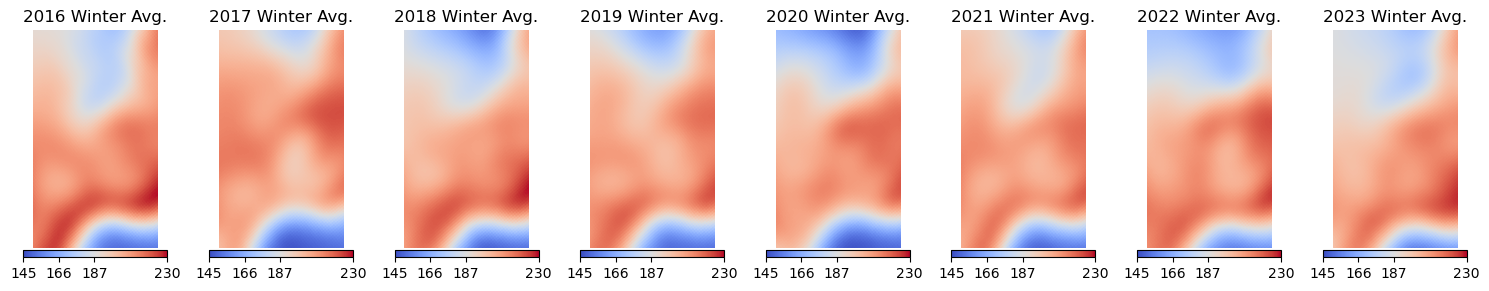

In [157]:
# Plot Winter means per year

import matplotlib.colors as colors

pmw_min = 145. # in Kelvin # 
pmw_max = 230. # in Kelvin # 273
pmw_vcenter = (pmw_max + pmw_min) /2. # in Kelvin # 225

ticks = np.concatenate(
    (np.linspace(pmw_min, pmw_vcenter, 2, endpoint=False), 
    np.linspace(pmw_vcenter, pmw_max, 2))).astype(int)
cnorms = colors.TwoSlopeNorm(vmin=pmw_min, vcenter=pmw_vcenter, vmax=pmw_max) # center colorbar around zero
cmaps = 'coolwarm'
xlabels = 'Brightness tempe-\nrature in K'

# Create winter mean for every year in dataset.
fig, axs = plt.subplots(1, len(df.index.year.unique()),figsize=(15,3),dpi=100)

for yr_id, yr in enumerate(df.index.year.unique()):
    output_filepath = data_root / path_pmw_winter_means / f'{yr}_jan_feb.tif'
    
    with rasterio.open(output_filepath) as dst:
        raster = dst.read(1)
        print('min,max', raster.min(), raster.max())
        ax = axs[yr_id].imshow(raster, cmap=cmaps, norm=cnorms)
        cbar = plt.colorbar(ax, orientation='horizontal', fraction=0.05, pad=0.01 , spacing='proportional', ticks=ticks)
        axs[yr_id].axes.set_axis_off()
        axs[yr_id].set_title(f'{yr} Winter Avg.')

plt.tight_layout()
dir_figures = f'../references/figures/data_exploration/data_v1_4/pmw_winter_means/'
Path(dir_figures).mkdir(parents=True, exist_ok=True)
plt.savefig(f"{dir_figures}{df.index.year.unique()[0]}_to_{df.index.year.unique()[-1]}_jan_feb.png")
plt.show()
plt.close()
